In [1]:
import pandas as pd

titanic = pd.read_csv('titanic.csv')

titanic['Age'] = titanic.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')

print(titanic[['Age', 'Embarked', 'Cabin']].isnull().sum())

Age         0
Embarked    0
Cabin       0
dtype: int64


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic['Sex_encoded'] = le.fit_transform(titanic['Sex'])

titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked')

print(titanic[['Sex', 'Sex_encoded']].head())
print(titanic.filter(like='Embarked').head())

      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
titanic[['Age_scaled', 'Fare_scaled']] = scaler.fit_transform(titanic[['Age', 'Fare']])

print(titanic[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head())

    Age  Age_scaled     Fare  Fare_scaled
0  22.0   -0.533834   7.2500    -0.502445
1  38.0    0.674891  71.2833     0.786845
2  26.0   -0.231653   7.9250    -0.488854
3  35.0    0.448255  53.1000     0.420730
4  35.0    0.448255   8.0500    -0.486337


In [4]:
features = ['Pclass', 'Age_scaled', 'SibSp', 'Parch', 'Fare_scaled', 'Sex_encoded',
            'Embarked_C', 'Embarked_Q', 'Embarked_S']

X = titanic[features]
y = titanic['Survived']

print(X.head())

   Pclass  Age_scaled  SibSp  Parch  Fare_scaled  Sex_encoded  Embarked_C  \
0       3   -0.533834      1      0    -0.502445            1       False   
1       1    0.674891      1      0     0.786845            0        True   
2       3   -0.231653      0      0    -0.488854            0       False   
3       1    0.448255      1      0     0.420730            0       False   
4       3    0.448255      0      0    -0.486337            1       False   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Survived ratio:\n", y_train.value_counts(normalize=True))
print("\nTest Survived ratio:\n", y_test.value_counts(normalize=True))

Train Survived ratio:
 Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test Survived ratio:
 Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


Accuracy: 0.8156424581005587


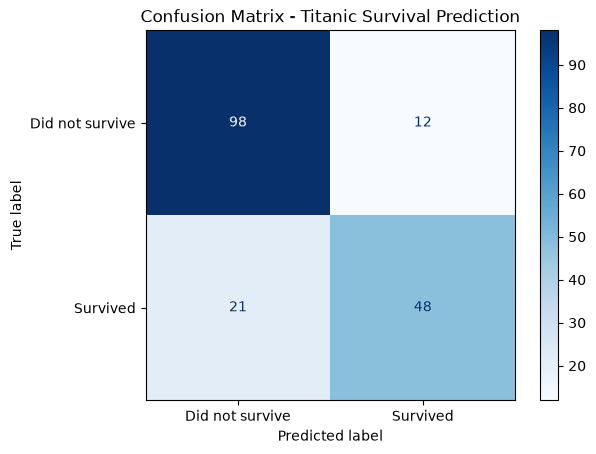

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Titanic Survival Prediction')
plt.show()

## Pipeline Summary

1. Fixed missing data - Age filled by median per class, Embarked filled with the most 
   common port, and Cabin's huge gap (77% missing) handled by just labeling it "Unknown" 
   instead of guessing.

2. Turned categories into numbers - Sex became 0/1 (only 2 options), Embarked became 
   3 separate yes/no columns (since 3 unordered options shouldn't be ranked like 1,2,3).

3. Scaled Age and Fare - since they're on very different number ranges, and some 
   models get confused by that.

4. Kept all features - instead of only the top 3 ones, kept all features otherwise accuracy drops

5. Split the data fairly - both train and test sets kept the same 
   survival ratio (~38%), since the classes weren't balanced.

6. Trained and tested the model - got about 82% accuracy. The confusion matrix showed 
   it made more mistakes predicting "died" for people who actually survived than the 
   other way around - likely because more people in the data died than survived overall.

Conclusion: how you handle missing data depends on how much is missing, removing 
"weak" features doesn't always help, and accuracy alone can hide important mistakes - 
which is exactly what the confusion matrix revealed here.